In [1]:
# Celda 1: Importar librerías y preparar datos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Cargar datos
data_path = r'C:\Users\LuisSalamanca\Desktop\Duoc\Machine\ML_Proyecto_Semestral\data\03_features\engineered_data.csv'
data = pd.read_csv(data_path, sep=';')

# Separar columnas concatenadas
if len(data.columns) == 1:
    column_name = data.columns[0]
    if ',' in column_name:
        new_columns = column_name.split(',')
        data_split = data[column_name].str.split(',', expand=True)
        data_split.columns = new_columns
        for col in data_split.columns:
            data_split[col] = pd.to_numeric(data_split[col], errors='coerce')
        data = data_split

# Crear variable objetivo multiclase
data['EffectivenessLevel'] = pd.cut(
    data['EffectivenessScore'].astype(float),
    bins=[-0.1, 0.5, 1.5, 5, np.inf],
    labels=['Bajo', 'Medio', 'Alto', 'Experto']
)

# Lista de features y target
features = [
    'EconomicEfficiency',
    'EquipmentAdvantage',
    'KillAssistRatio',
    'StealthKillsRatio',
    'KDA'
]
X = data[features]
y = data['EffectivenessLevel']

# Dividir en entrenamiento/prueba (30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Escalamiento de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir los arrays escalados en DataFrame para fácil indexación por nombre
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)
X_test_scaled_df  = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

print("Formas de los datos:")
print(f"  X_train:           {X_train.shape}")
print(f"  X_test:            {X_test.shape}")
print(f"  X_train_scaled_df: {X_train_scaled_df.shape}")
print(f"  X_test_scaled_df:  {X_test_scaled_df.shape}")


Formas de los datos:
  X_train:           (55120, 5)
  X_test:            (23624, 5)
  X_train_scaled_df: (55120, 5)
  X_test_scaled_df:  (23624, 5)


c:\Users\LuisSalamanca\miniconda3\envs\machine_csgo\lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


Mejores parámetros: {'clf__activation': 'relu', 'clf__hidden_layer_sizes': (50,)}
              precision    recall  f1-score   support

        Alto      0.998     0.991     0.994      9848
        Bajo      1.000     1.000     1.000     11073
     Experto      1.000     0.978     0.989      1076
       Medio      0.948     1.000     0.973      1627

    accuracy                          0.995     23624
   macro avg      0.986     0.992     0.989     23624
weighted avg      0.995     0.995     0.995     23624



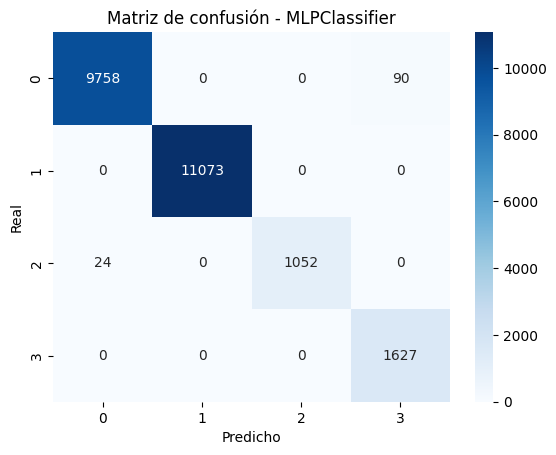

In [2]:
pipe_mlp = Pipeline([
    ('clf', MLPClassifier(max_iter=300, random_state=42))
])

param_grid_mlp = {
    'clf__hidden_layer_sizes': [(50,), (100,)],
    'clf__activation': ['relu', 'tanh']
}

grid_mlp = GridSearchCV(pipe_mlp, param_grid_mlp, cv=3, scoring='f1', n_jobs=-1)
grid_mlp.fit(X_train_scaled_df, y_train)

y_pred_mlp = grid_mlp.predict(X_test_scaled_df)

print("Mejores parámetros:", grid_mlp.best_params_)
print(classification_report(y_test, y_pred_mlp, digits=3))

cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - MLPClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()


C:\Users\LuisSalamanca\AppData\Local\Temp\ipykernel_18028\1079761029.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(classes))


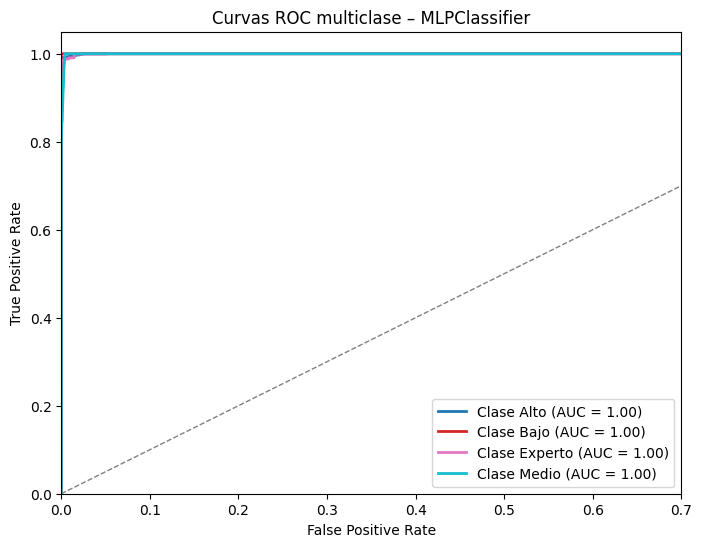

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Binarizar etiquetas de test según las clases de grid_mlp
classes = grid_mlp.classes_
y_test_bin = label_binarize(y_test, classes=classes)

# 2. Obtener probabilidades para cada clase
y_score = grid_mlp.predict_proba(X_test_scaled_df)  # shape (n_samples, n_classes)

# 3. Calcular FPR, TPR y AUC para cada clase
fpr = {}
tpr = {}
roc_auc = {}
for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plotear curvas ROC multiclase
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', len(classes))

for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Clase {cls} (AUC = {roc_auc[i]:.2f})',
             color=colors(i))

# Línea de referencia aleatoria
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC multiclase – MLPClassifier')
plt.legend(loc='lower right')
plt.show()
